<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/khushalha/notebooks/SentinelNetproj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import RFE
import itertools
import time
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier

In [92]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train=pd.read_csv("/content/drive/MyDrive/KDDTrain+_20Percent.txt",names=col_names)
test=pd.read_csv("/content/drive/MyDrive/KDDTest-21.txt",names=col_names)
train.drop(['difficulty'], axis=1, inplace=True)
test.drop(['difficulty'], axis=1, inplace=True)


In [93]:
print("---Training Data---")
print(f"Shape: {train.shape}")
print("\n---Test Data---")
print(f"Shape: {test.shape}")

---Training Data---
Shape: (25192, 42)

---Test Data---
Shape: (11850, 42)


In [94]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [95]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,10,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd
1,0,udp,private,SF,44,0,0,0,0,0,...,254,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,79,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable
3,0,udp,private,SF,53,55,0,0,0,0,...,255,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal
4,0,tcp,private,SH,0,0,0,0,0,0,...,1,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap


In [96]:
train.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
25187,0,tcp,exec,RSTO,0,0,0,0,0,0,...,7,0.03,0.06,0.00,0.00,0.0,0.0,1.0,1.0,neptune
25188,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,39,1.00,0.00,1.00,0.18,0.0,0.0,0.0,0.0,warezclient
25189,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.0,0.0,1.0,1.0,neptune
25190,0,tcp,nnsp,S0,0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.0,1.0,0.0,0.0,neptune
25191,0,tcp,finger,S0,0,0,0,0,0,0,...,49,0.19,0.03,0.01,0.00,1.0,1.0,0.0,0.0,neptune


In [97]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [98]:
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [99]:
print("Total missing values:",train.isnull().sum().sum())
train=train.dropna()

Total missing values: 0


In [100]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [101]:
train.describe(include="object")

,protocol_type,service,flag,label
count,25192,25192,25192,25192
unique,3,66,11,22
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [102]:
print("Before removing duplicates:", train.shape)
train = train.drop_duplicates()
print("After removing duplicates:", train.shape)

Before removing duplicates: (25192, 42)
After removing duplicates: (25192, 42)


/tmp/ipython-input-4175320351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")


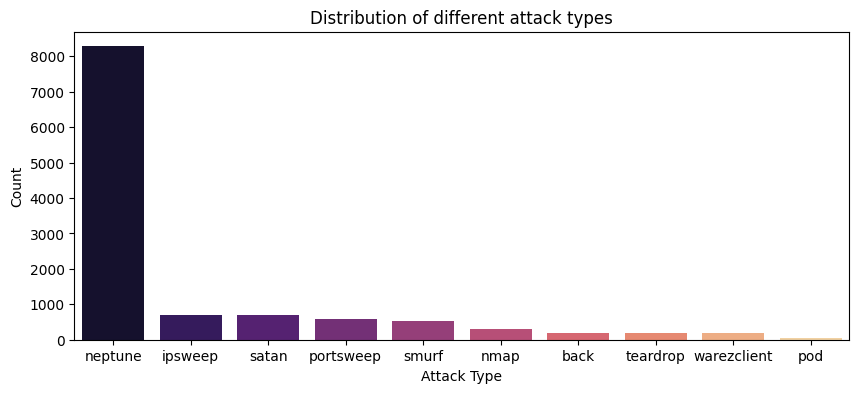

In [103]:
plt.figure(figsize=(10,4))
df_attacks=train["label"]
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")
plt.title("Distribution of different attack types")
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-1952988367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="attack",data=train, palette="viridis")


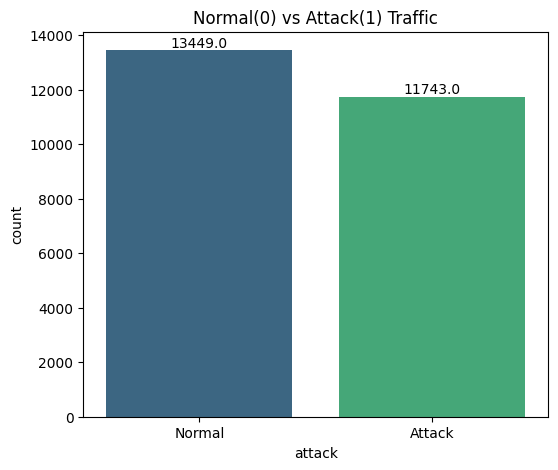

/tmp/ipython-input-1952988367.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="attack",data=test, palette="viridis")


attack
0    0.53386
1    0.46614
Name: proportion, dtype: float64


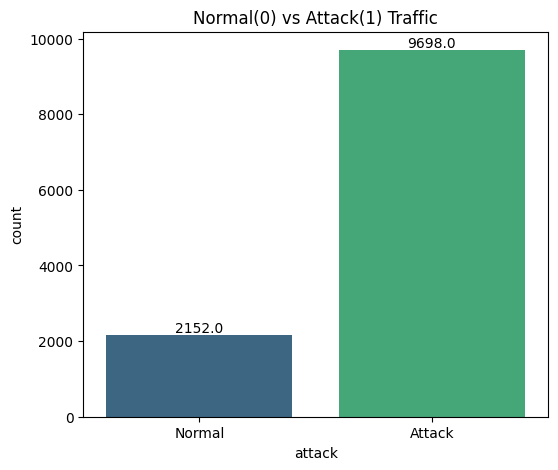

attack
1    0.818397
0    0.181603
Name: proportion, dtype: float64


In [104]:
train['attack']=train['label'].apply(lambda x: 0 if x=='normal' else 1)
test['attack']=test['label'].apply(lambda x: 0 if x=='normal' else 1)

plt.figure(figsize=(6,5))
ax = sns.countplot(x="attack",data=train, palette="viridis")
plt.title("Normal(0) vs Attack(1) Traffic")
plt.xticks([0,1],["Normal","Attack"])

# Add counts to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

print(train['attack'].value_counts(normalize=True))

plt.figure(figsize=(6,5))
ax = sns.countplot(x="attack",data=test, palette="viridis")
plt.title("Normal(0) vs Attack(1) Traffic")
plt.xticks([0,1],["Normal","Attack"])

# Add counts to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

print(test['attack'].value_counts(normalize=True))

In [105]:
print(train.shape)
print(test.shape)

(25192, 43)
(11850, 43)


/tmp/ipython-input-2746560264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='protocol_type', data=train, palette='magma')
/tmp/ipython-input-2746560264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='service', data=train, order=train['service'].value_counts().iloc[:10].index, palette='plasma')
/tmp/ipython-input-2746560264.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[2], x='flag', data=train, order=train['flag'].value_counts().index, palette='cividis')


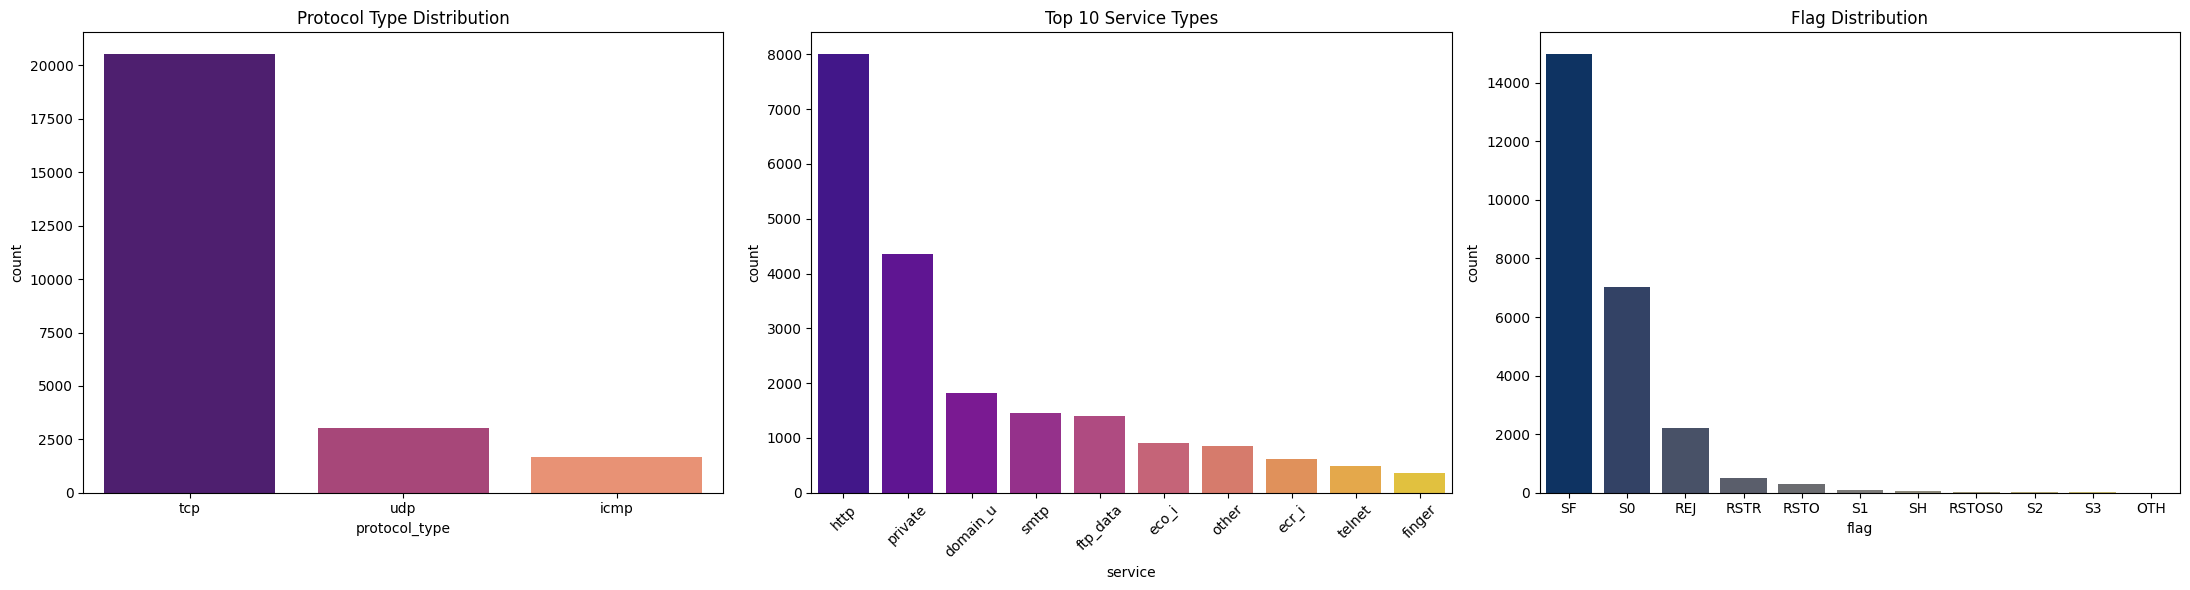

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(ax=axes[0], x='protocol_type', data=train, palette='magma')
axes[0].set_title('Protocol Type Distribution')

sns.countplot(ax=axes[1], x='service', data=train, order=train['service'].value_counts().iloc[:10].index, palette='plasma')
axes[1].set_title('Top 10 Service Types')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[2], x='flag', data=train, order=train['flag'].value_counts().index, palette='cividis')
axes[2].set_title('Flag Distribution')

plt.tight_layout()
plt.show()

In [107]:
def le(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      label_encoder=LabelEncoder()
      df[col]=label_encoder.fit_transform(df[col])
le(train)
le(test)

In [108]:
train.drop(['num_outbound_cmds'],axis=1,inplace=True)
test.drop(['num_outbound_cmds'],axis=1,inplace=True)

In [109]:
print(f"Shape of training data after encoding: {train.shape}")
print(f"Shape of testing data after encoding: {test.shape}")

Shape of training data after encoding: (25192, 42)
Shape of testing data after encoding: (11850, 42)


In [110]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,attack
0,0,1,19,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11,0
1,0,2,41,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11,0
2,0,1,46,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9,1
3,0,1,22,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11,0
4,0,1,22,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11,0


In [111]:
x_train=train.drop(['label','attack'],axis=1)
y_train=train['attack']

In [112]:
x_train.shape

(25192, 40)

In [113]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
test=scale.fit_transform(test)

In [114]:
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [115]:
x_train.shape

(20153, 40)

In [116]:
x_test.shape

(5039, 40)

In [117]:
y_test.shape

(5039,)

In [118]:
y_train.shape

(20153,)

▶ Training Logistic Regression
Training Time: 1.86s | Testing Time: 0.00s
Train Accuracy: 0.9542 | Test Accuracy: 0.9563

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2674
           1       0.96      0.95      0.95      2365

    accuracy                           0.96      5039
   macro avg       0.96      0.96      0.96      5039
weighted avg       0.96      0.96      0.96      5039



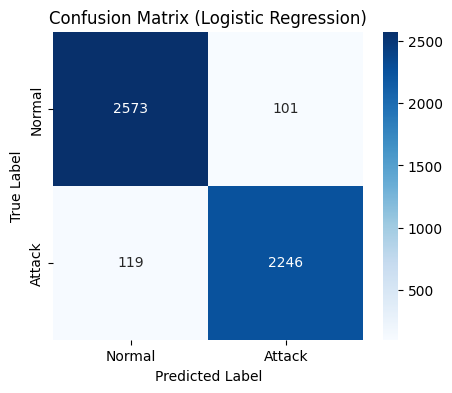

▶ Training Random Forest
Training Time: 2.46s | Testing Time: 0.08s
Train Accuracy: 1.0000 | Test Accuracy: 0.9976

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2674
           1       1.00      1.00      1.00      2365

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



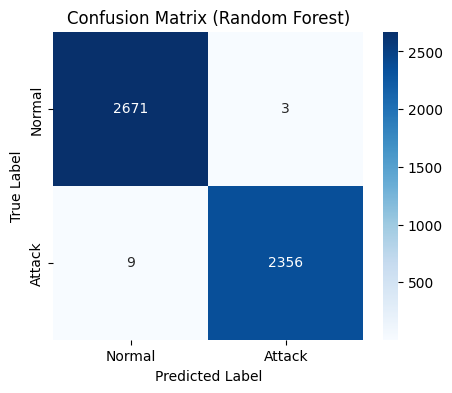

▶ Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:42:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Time: 0.40s | Testing Time: 0.01s
Train Accuracy: 1.0000 | Test Accuracy: 0.9984

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2674
           1       1.00      1.00      1.00      2365

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



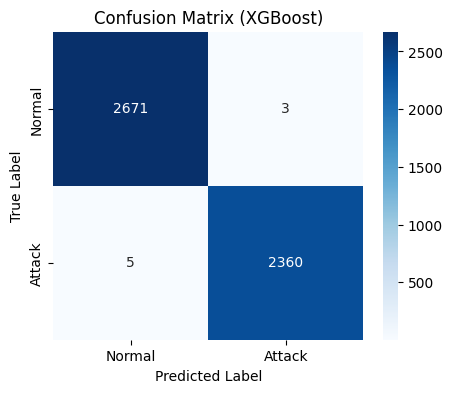

▶ Training SVM
Training Time: 13.26s | Testing Time: 0.59s
Train Accuracy: 0.9919 | Test Accuracy: 0.9903

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2674
           1       0.99      0.99      0.99      2365

    accuracy                           0.99      5039
   macro avg       0.99      0.99      0.99      5039
weighted avg       0.99      0.99      0.99      5039



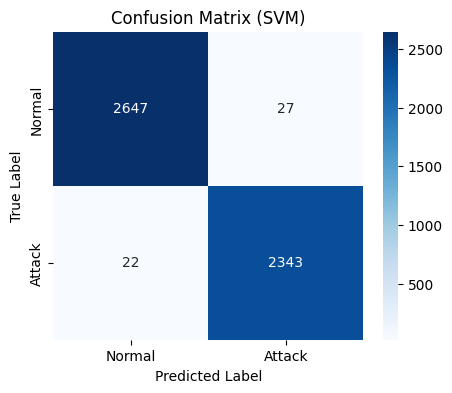

In [119]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

results = {}

# Train, evaluate, and show confusion matrix
for name, model in models.items():
    print("="*60)
    print(f"▶ Training {name}")

    # Training time
    start = time.time()
    model.fit(x_train, y_train)
    train_time = time.time() - start

    # Training performance
    y_train_pred = model.predict(x_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Testing time
    start = time.time()
    y_test_pred = model.predict(x_test)
    test_time = time.time() - start
    test_acc = accuracy_score(y_test, y_test_pred)

    # Store results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Training Time": train_time,
        "Testing Time": test_time,
        "Confusion Matrix": confusion_matrix(y_test, y_test_pred),
        "Classification Report": classification_report(y_test, y_test_pred)
    }

    # Print results
    print(f"Training Time: {train_time:.2f}s | Testing Time: {test_time:.2f}s")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Attack"],
                yticklabels=["Normal","Attack"])
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

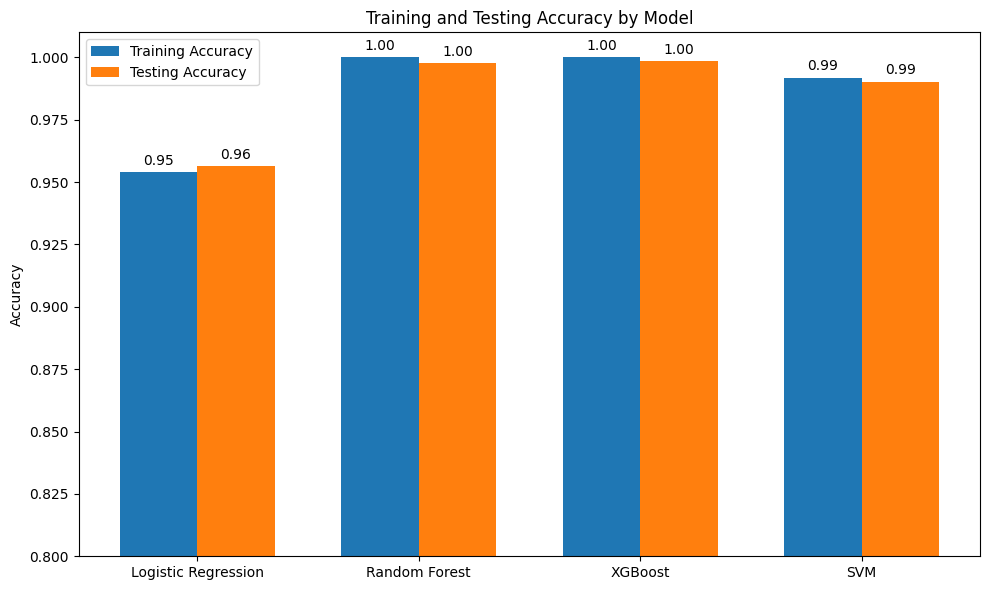

In [120]:
model_names = list(results.keys())
train_accuracy = [metrics['Train Accuracy'] for metrics in results.values()]
test_accuracy = [metrics['Test Accuracy'] for metrics in results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training and Testing Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization
plt.tight_layout()
plt.show()

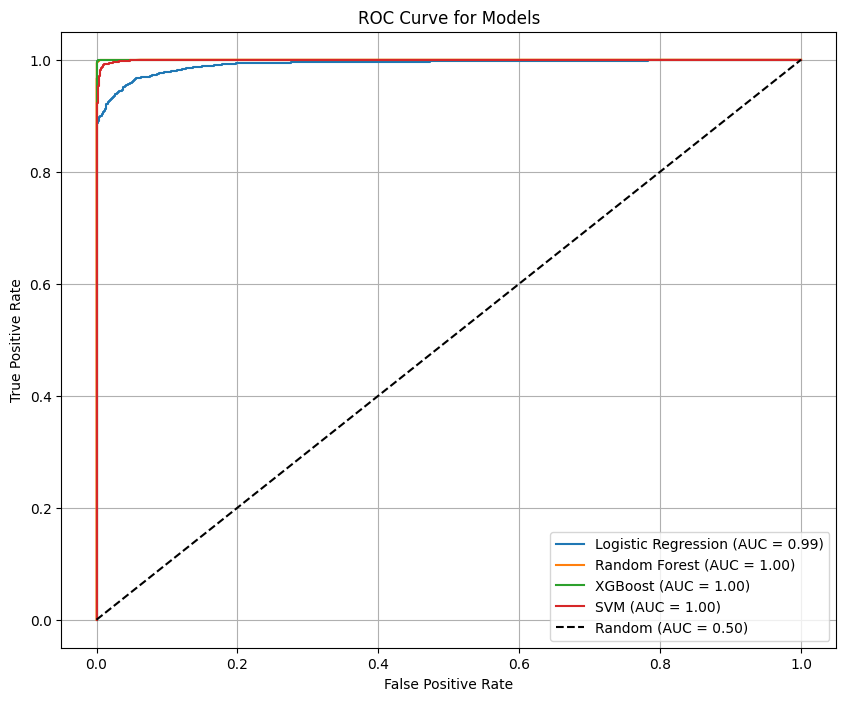

In [121]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Models')
plt.legend()
plt.grid(True)
plt.show()